## Feature Engineering and Model Development 

### Setup & Loading Clean Halfway Dataset

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, PrecisionRecallDisplay, RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, AdaBoostClassifier
)
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Load the leak-free clean halfway dataset (13,895 rows × 38 columns)
df_raw_halfway_clean = pd.read_csv('../../data/clean/dataset_at_halfway_clean.csv')

print(f"=== CLEAN HALFWAY DATASET LOADED ===")
print(f"Total Rows: {len(df_raw_halfway_clean):,} | Raw Features: {df_raw_halfway_clean.shape[1]}")
print(f"Baseline Overdue Rate: {df_raw_halfway_clean['calculated_overdue'].mean()*100:.2f}% ({df_raw_halfway_clean['calculated_overdue'].sum():,} overdue tasks)")

=== CLEAN HALFWAY DATASET LOADED ===
Total Rows: 13,895 | Raw Features: 38
Baseline Overdue Rate: 47.81% (6,643 overdue tasks)


### Feature Engineering & Data Preprocessing Pipeline

In [13]:
def preprocess_clean_halfway_features(df_input):
    df = df_input.copy()

    # 1. Clip negative planned durations
    if 'planned_duration' in df.columns:
        df['planned_duration'] = df['planned_duration'].clip(lower=0)

    # 2. Outlier capping (99th percentile)
    if 'num_ma_revisions' in df.columns:
        df['num_ma_revisions'] = df['num_ma_revisions'].clip(upper=78)
    if 'num_revisions' in df.columns:
        df['num_revisions'] = df['num_revisions'].clip(upper=9)

    # 3. Domain Interaction Feature (Revision Intensity per Planned Day)
    if 'planned_duration' in df.columns and 'num_revisions' in df.columns:
        df['duration_revision_intensity'] = df['num_revisions'] / (df['planned_duration'] + 1)

    # 4. Drop non-predictive, redundant, or outcome status columns as specified in PR
    cols_to_drop = [
        'id', 'target_source', 'status_encoded', 'approval_status_encoded',
        'lead_approval_status_encoded', 'ma_status_encoded', 'ma_approval_status_encoded',
        'subtask_completion_pct', 'subtask_overdue_rate', 'created_is_weekend', 'created_is_friday'
    ]
    return df.drop(columns=[c for c in cols_to_drop if c in df.columns], errors='ignore')

df_halfway_clean = preprocess_clean_halfway_features(df_raw_halfway_clean)

X = df_halfway_clean.drop(columns=['calculated_overdue'])
y = df_halfway_clean['calculated_overdue']

print(f"Clean Predictor Features: {X.shape[1]} predictor columns")

Clean Predictor Features: 27 predictor columns


## Time Based Split Model Training Approach

### Data Splitting (Time-Based & 3-Way Train / Validation / Test)

In [24]:
# Sort chronologically by creation time (quarter & month)
df_clean_sorted = df_halfway_clean.sort_values(by=['created_quarter', 'created_month']).reset_index(drop=True)

X = df_clean_sorted.drop(columns=['calculated_overdue'])
y = df_clean_sorted['calculated_overdue']

n_total = len(df_clean_sorted)
train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val     = X.iloc[train_end:val_end], y.iloc[train_end:val_end]
X_test, y_test   = X.iloc[val_end:], y.iloc[val_end:]

print(f"=== TIME-BASED CHRONOLOGICAL DATA SPLIT COMPLETED ===")
print(f"  • Train Set: {len(X_train):,} rows ({y_train.mean()*100:.2f}% overdue)")
print(f"  • Val Set:   {len(X_val):,} rows ({y_val.mean()*100:.2f}% overdue)")
print(f"  • Test Set:  {len(X_test):,} rows ({y_test.mean()*100:.2f}% overdue)")


=== TIME-BASED CHRONOLOGICAL DATA SPLIT COMPLETED ===
  • Train Set: 9,726 rows (45.49% overdue)
  • Val Set:   2,084 rows (62.38% overdue)
  • Test Set:  2,085 rows (44.08% overdue)


###  Candidate Model Training & Benchmark Evaluation(Time based Split)

In [ ]:
candidate_models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    'Naive Bayes (Gaussian)': Pipeline([('scaler', StandardScaler()), ('model', GaussianNB())]),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'K-Nearest Neighbors': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=15))]),
    'Support Vector Machine (RBF)': Pipeline([('scaler', StandardScaler()), ('model', SVC(probability=True, kernel='rbf', C=1.0, random_state=42))]),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=5, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1)
}

results_clean_time = []

for name, model in candidate_models.items():
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_val_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_val_proba = model.decision_function(X_val)

    pr_auc = average_precision_score(y_val, y_val_proba)
    roc_auc = roc_auc_score(y_val, y_val_proba)

    y_val_pred = (y_val_proba >= 0.50).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='binary')

    results_clean_time.append({
        'Model Name': name,
        'PR-AUC': round(pr_auc, 4),
        'ROC-AUC': round(roc_auc, 4),
        'Precision@0.50': round(p, 4),
        'Recall@0.50': round(r, 4),
        'F1-Score@0.50': round(f1, 4)
    })

df_bm_time = pd.DataFrame(results_clean_time).sort_values(by='PR-AUC', ascending=False)
print("=== 11 CANDIDATE MODEL BENCHMARK (CLEAN TIME-BASED VALIDATION SET) ===")
print(df_bm_time.to_string(index=False))


=== 11 CANDIDATE MODEL BENCHMARK (CLEAN TIME-BASED VALIDATION SET) ===
                  Model Name  PR-AUC  ROC-AUC  Precision@0.50  Recall@0.50  F1-Score@0.50
                    LightGBM  0.8827   0.7957          0.6952       0.9546         0.8045
                     XGBoost  0.8808   0.7919          0.6935       0.9662         0.8075
           Gradient Boosting  0.8698   0.7800          0.7028       0.9477         0.8071
               Random Forest  0.8585   0.7693          0.6692       0.9992         0.8016
                    AdaBoost  0.8359   0.7490          0.6588       0.9492         0.7778
                 Extra Trees  0.7941   0.7036          0.6672       0.9992         0.8001
         K-Nearest Neighbors  0.7521   0.6919          0.6779       0.9469         0.7901
         Logistic Regression  0.7224   0.6211          0.6294       0.9992         0.7723
      Naive Bayes (Gaussian)  0.7125   0.6177          0.6236       0.9992         0.7680
               Decision Tree 

###  Hyperparameter Tuning & Model Saving (LightGBM)

In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist_lgb = {
    'n_estimators': [100, 150],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [15, 31]
}

# Set n_jobs=1 inside LGBM to prevent OpenMP thread locking
lgb_base = lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=1)

random_search_lgb = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist_lgb,
    n_iter=5,
    scoring='average_precision',
    cv=skf,
    n_jobs=2,  
    random_state=42
)

random_search_lgb.fit(X_train, y_train)
best_lgb_clean = random_search_lgb.best_estimator_

print(f"\n✅ Tuning Completed!")
print(f"Best Parameters: {random_search_lgb.best_params_}")
print(f"Best CV PR-AUC Score: {random_search_lgb.best_score_:.4f}")

# Save the Best Clean Model
os.makedirs('../models', exist_ok=True)
save_clean_path = '../models/v1_halfway_clean_lightgbm.joblib'
joblib.dump(best_lgb_clean, save_clean_path)
print(f"💾 Model saved to: {save_clean_path}")


✅ Tuning Completed!
Best Parameters: {'num_leaves': 15, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1}
Best CV PR-AUC Score: 0.9517
💾 Model saved to: ../models/v1_halfway_clean_lightgbm.joblib


### Held-Out Test Set Evaluation & Generalization Gap

In [25]:
# Retrain best tuned LightGBM model on combined Train+Validation sets (first 85% of time)
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

best_lgb_clean.fit(X_train_val, y_train_val)

y_train_val_probs = best_lgb_clean.predict_proba(X_train_val)[:, 1]
y_test_probs = best_lgb_clean.predict_proba(X_test)[:, 1]

train_val_pr = average_precision_score(y_train_val, y_train_val_probs)
test_pr = average_precision_score(y_test, y_test_probs)

print("=== CLEAN DATASET TIME-BASED OVERFITTING & GENERALIZATION EVALUATION ===")
print(f"Train+Val PR-AUC     : {train_val_pr:.4f}")
print(f"Held-Out Test PR-AUC : {test_pr:.4f}")
print(f"Generalization Gap   : {abs(train_val_pr - test_pr):.4f}")

print("\n=== FINAL HELD-OUT TEST SET REPORT (Threshold = 0.50) ===")
print(classification_report(y_test, (y_test_probs >= 0.50).astype(int), target_names=['On-Time', 'Overdue']))

print("\n=== FINAL HELD-OUT TEST SET REPORT (Threshold = 0.40) ===")
print(classification_report(y_test, (y_test_probs >= 0.40).astype(int), target_names=['On-Time', 'Overdue']))


=== CLEAN DATASET TIME-BASED OVERFITTING & GENERALIZATION EVALUATION ===
Train+Val PR-AUC     : 0.9674
Held-Out Test PR-AUC : 0.7931
Generalization Gap   : 0.1742

=== FINAL HELD-OUT TEST SET REPORT (Threshold = 0.50) ===
              precision    recall  f1-score   support

     On-Time       0.84      0.42      0.56      1166
     Overdue       0.55      0.90      0.68       919

    accuracy                           0.63      2085
   macro avg       0.70      0.66      0.62      2085
weighted avg       0.71      0.63      0.62      2085


=== FINAL HELD-OUT TEST SET REPORT (Threshold = 0.40) ===
              precision    recall  f1-score   support

     On-Time       0.90      0.26      0.41      1166
     Overdue       0.51      0.96      0.66       919

    accuracy                           0.57      2085
   macro avg       0.71      0.61      0.54      2085
weighted avg       0.73      0.57      0.52      2085



### Complete Feature Importance Analysis (ALL Features)

=== COMPLETE FEATURE IMPORTANCE RANKING (ALL FEATURES) ===
                              Feature  Importance_Split_Count
0                   days_since_update                     549
1           creation_to_planned_start                     294
2              dept_past_overdue_rate                     174
3                    planned_duration                     162
4                  dept_avg_revisions                     140
5               emp_past_overdue_rate                     125
6               pos_past_overdue_rate                     118
7                    revision_recency                     115
8                       created_month                      99
9                        risk_mapping                      75
10                        created_dow                      63
11                  num_kpi_revisions                      46
12                   num_ma_revisions                      40
13                      num_revisions                      20
14        d

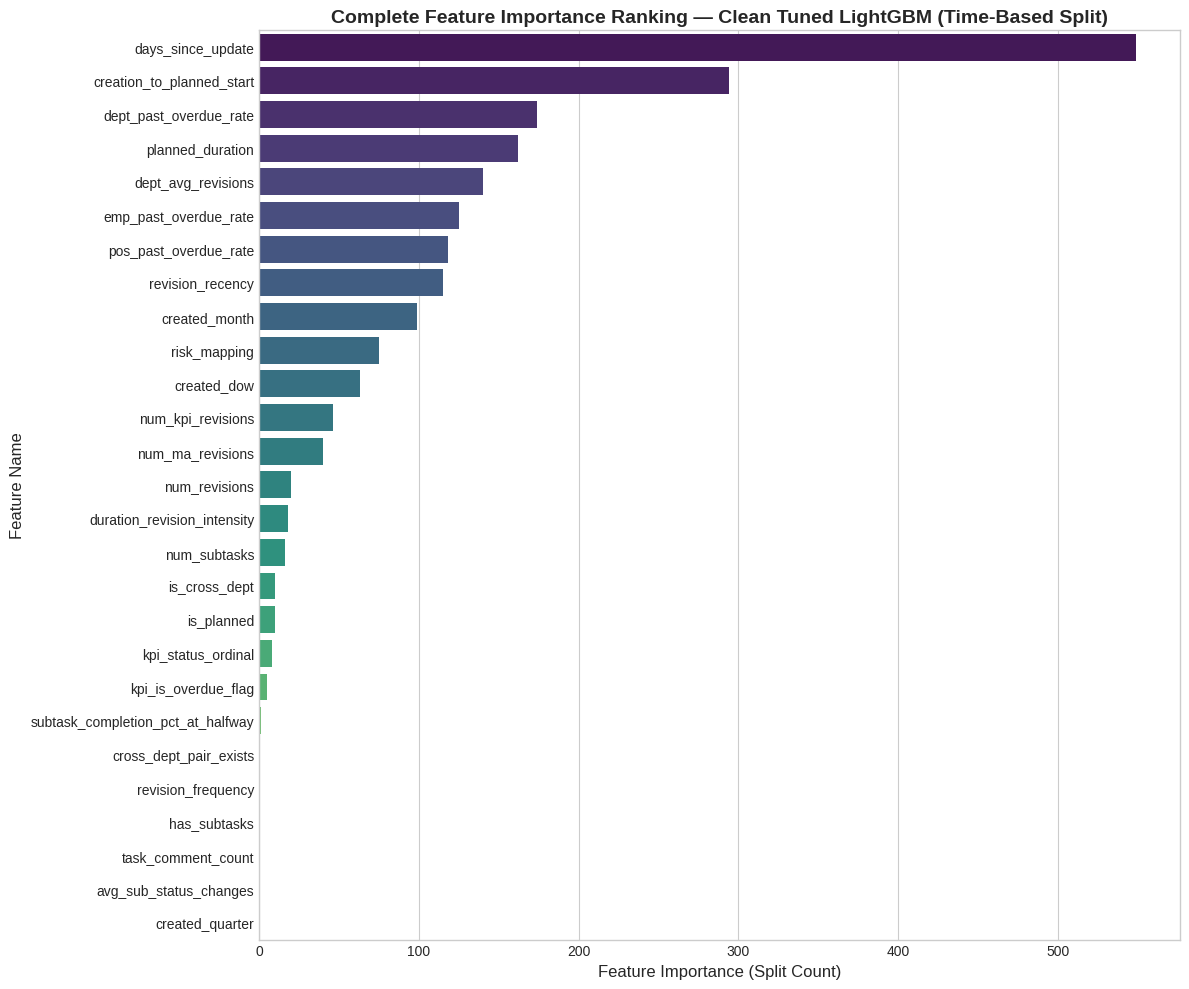

In [21]:
# Extract feature importances for ALL features
df_all_fi = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Split_Count': best_lgb_clean.feature_importances_
}).sort_values(by='Importance_Split_Count', ascending=False).reset_index(drop=True)

print("=== COMPLETE FEATURE IMPORTANCE RANKING (ALL FEATURES) ===")
print(df_all_fi.to_string())

# Plot Importance for ALL Features
plt.figure(figsize=(12, 10))
sns.barplot(
    x='Importance_Split_Count',
    y='Feature',
    data=df_all_fi,
    palette='viridis'
)
plt.title('Complete Feature Importance Ranking — Clean Tuned LightGBM (Time-Based Split)', fontweight='bold', fontsize=14)
plt.xlabel('Feature Importance (Split Count)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

### Visualizations — PR Curve, ROC Curve & Confusion Matrix

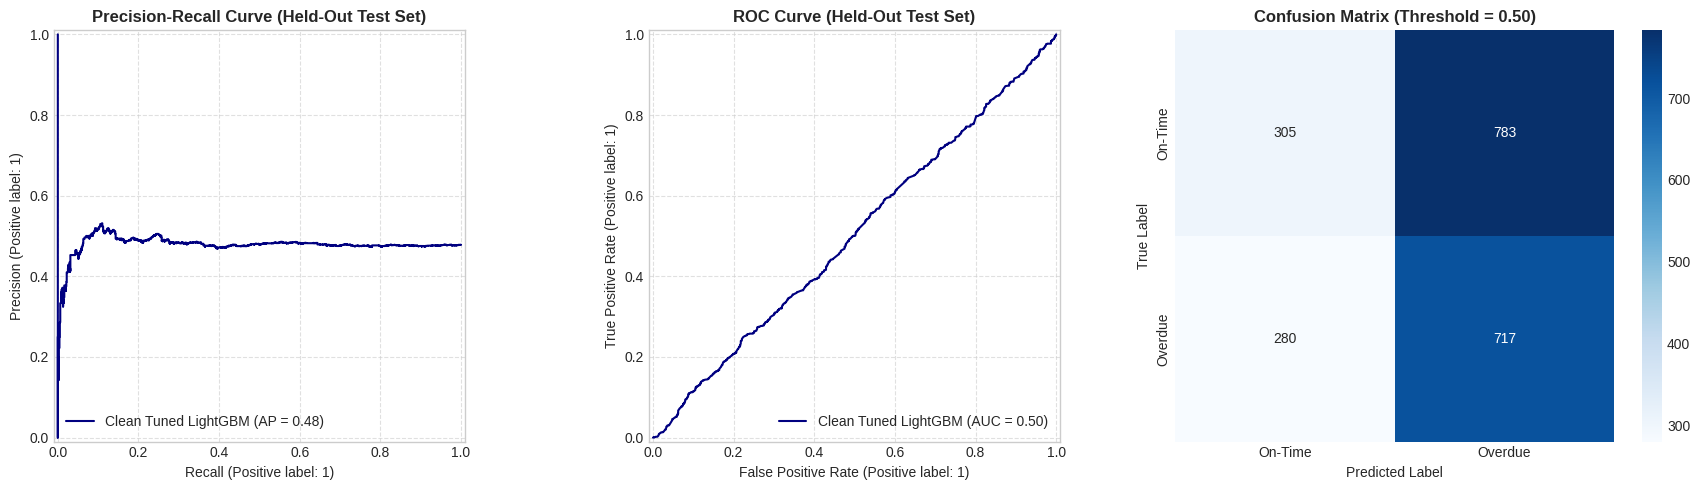

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Precision-Recall Curve on Test Set
PrecisionRecallDisplay.from_predictions(
    y_test, y_test_probs, name='Clean Tuned LightGBM', ax=axes[0], color='navy'
)
axes[0].set_title('Precision-Recall Curve (Held-Out Test Set)', fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. ROC Curve on Test Set
RocCurveDisplay.from_predictions(
    y_test, y_test_probs, name='Clean Tuned LightGBM', ax=axes[1], color='navy'
)
axes[1].set_title('ROC Curve (Held-Out Test Set)', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Confusion Matrix at Threshold 0.50
cm = confusion_matrix(y_test, (y_test_probs >= 0.50).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['On-Time', 'Overdue'], yticklabels=['On-Time', 'Overdue'])
axes[2].set_title('Confusion Matrix (Threshold = 0.50)', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

## Random Split Model Training Approach

### Data Splitting(Random)

In [26]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"=== STRATIFIED DATA SPLIT COMPLETED ===")
print(f"  • Train Set: {len(X_train):,} rows ({y_train.mean()*100:.2f}% overdue)")
print(f"  • Val Set:   {len(X_val):,} rows ({y_val.mean()*100:.2f}% overdue)")
print(f"  • Test Set:  {len(X_test):,} rows ({y_test.mean()*100:.2f}% overdue)")

=== STRATIFIED DATA SPLIT COMPLETED ===
  • Train Set: 9,726 rows (47.81% overdue)
  • Val Set:   2,084 rows (47.79% overdue)
  • Test Set:  2,085 rows (47.82% overdue)


### Candidate Model Training & Benchmark Evaluation(on Random Split)

In [19]:
candidate_models = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000, random_state=42))]),
    'Naive Bayes (Gaussian)': Pipeline([('scaler', StandardScaler()), ('model', GaussianNB())]),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'K-Nearest Neighbors': Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=15))]),
    'Support Vector Machine (RBF)': Pipeline([('scaler', StandardScaler()), ('model', SVC(probability=True, kernel='rbf', C=1.0, random_state=42))]),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=5, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1)
}

results_clean = []

for name, model in candidate_models.items():
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_val_proba = model.predict_proba(X_val)[:, 1]
    else:
        y_val_proba = model.decision_function(X_val)

    pr_auc = average_precision_score(y_val, y_val_proba)
    roc_auc = roc_auc_score(y_val, y_val_proba)

    y_val_pred = (y_val_proba >= 0.50).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_val, y_val_pred, average='binary')

    results_clean.append({
        'Model Name': name,
        'PR-AUC': round(pr_auc, 4),
        'ROC-AUC': round(roc_auc, 4),
        'Precision@0.50': round(p, 4),
        'Recall@0.50': round(r, 4),
        'F1-Score@0.50': round(f1, 4)
    })

df_benchmark_clean = pd.DataFrame(results_clean).sort_values(by='PR-AUC', ascending=False)
print("=== 11 CANDIDATE MODEL BENCHMARK (CLEAN HALFWAY RANDOM SPLIT VALIDATION SET) ===")
print(df_benchmark_clean.to_string(index=False))

=== 11 CANDIDATE MODEL BENCHMARK (CLEAN HALFWAY RANDOM SPLIT VALIDATION SET) ===
                  Model Name  PR-AUC  ROC-AUC  Precision@0.50  Recall@0.50  F1-Score@0.50
           Gradient Boosting  0.9456   0.9431          0.8809       0.8243         0.8517
               Random Forest  0.9339   0.9261          0.8764       0.7972         0.8349
                     XGBoost  0.9244   0.9156          0.8709       0.7721         0.8185
                    LightGBM  0.9229   0.9140          0.8652       0.7671         0.8132
                 Extra Trees  0.8856   0.8822          0.8011       0.7600         0.7800
               Decision Tree  0.8685   0.8731          0.8180       0.7942         0.8059
                    AdaBoost  0.8685   0.8491          0.8132       0.6948         0.7493
Support Vector Machine (RBF)  0.8542   0.8395          0.7630       0.7369         0.7497
         K-Nearest Neighbors  0.8524   0.8549          0.8150       0.7078         0.7577
         Logistic R

### Hyperparameter Tuning & Model Saving (Gradient Boosting — Random Split)

In [27]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist_gb = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'max_features': ['sqrt', 'log2', None]
}

gb_base = GradientBoostingClassifier(random_state=42)

random_search_gb = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=param_dist_gb,
    n_iter=8,
    scoring='average_precision',
    cv=skf,
    n_jobs=-1,
    random_state=42
)

random_search_gb.fit(X_train, y_train)
best_gb_clean = random_search_gb.best_estimator_

print(f"\n✅ Tuning Completed for Clean Gradient Boosting Model!")
print(f"Best Parameters: {random_search_gb.best_params_}")
print(f"Best CV PR-AUC Score: {random_search_gb.best_score_:.4f}")

# Save Model
os.makedirs('../models', exist_ok=True)
save_clean_path = '../models/v1_halfway_clean_gradientboosting.joblib'
joblib.dump(best_gb_clean, save_clean_path)
print(f"💾 Model saved to: {save_clean_path}")


✅ Tuning Completed for Clean Gradient Boosting Model!
Best Parameters: {'subsample': 0.9, 'n_estimators': 150, 'max_features': None, 'max_depth': 5, 'learning_rate': 0.1}
Best CV PR-AUC Score: 0.9412
💾 Model saved to: ../models/v1_halfway_clean_gradientboosting.joblib


###  Held-Out Test Set Evaluation & Generalization Gap (Random Split)

In [28]:
# Retrain best Gradient Boosting model on Train+Validation set
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

best_gb_clean.fit(X_train_val, y_train_val)

y_train_val_probs = best_gb_clean.predict_proba(X_train_val)[:, 1]
y_test_probs = best_gb_clean.predict_proba(X_test)[:, 1]

train_val_pr = average_precision_score(y_train_val, y_train_val_probs)
test_pr = average_precision_score(y_test, y_test_probs)

print("=== CLEAN DATASET STRATIFIED RANDOM SPLIT OVERFITTING & GENERALIZATION EVALUATION ===")
print(f"Train+Val PR-AUC     : {train_val_pr:.4f}")
print(f"Held-Out Test PR-AUC : {test_pr:.4f}")
print(f"Generalization Gap   : {abs(train_val_pr - test_pr):.4f}")

print("\n=== FINAL HELD-OUT TEST SET REPORT (Threshold = 0.50) ===")
print(classification_report(y_test, (y_test_probs >= 0.50).astype(int), target_names=['On-Time', 'Overdue']))

print("\n=== FINAL HELD-OUT TEST SET REPORT (Threshold = 0.40) ===")
print(classification_report(y_test, (y_test_probs >= 0.40).astype(int), target_names=['On-Time', 'Overdue']))


=== CLEAN DATASET STRATIFIED RANDOM SPLIT OVERFITTING & GENERALIZATION EVALUATION ===
Train+Val PR-AUC     : 0.9773
Held-Out Test PR-AUC : 0.9475
Generalization Gap   : 0.0298

=== FINAL HELD-OUT TEST SET REPORT (Threshold = 0.50) ===
              precision    recall  f1-score   support

     On-Time       0.84      0.92      0.88      1088
     Overdue       0.90      0.81      0.86       997

    accuracy                           0.87      2085
   macro avg       0.87      0.87      0.87      2085
weighted avg       0.87      0.87      0.87      2085


=== FINAL HELD-OUT TEST SET REPORT (Threshold = 0.40) ===
              precision    recall  f1-score   support

     On-Time       0.88      0.87      0.88      1088
     Overdue       0.86      0.88      0.87       997

    accuracy                           0.87      2085
   macro avg       0.87      0.87      0.87      2085
weighted avg       0.87      0.87      0.87      2085



### Complete Feature Importance Analysis (ALL Features)

=== COMPLETE FEATURE IMPORTANCE RANKING (Gradient Boosting) ===
                              Feature  Importance
0                   days_since_update    0.296215
1           creation_to_planned_start    0.262295
2               emp_past_overdue_rate    0.081744
3                    planned_duration    0.061490
4              dept_past_overdue_rate    0.054199
5                        risk_mapping    0.048395
6                       created_month    0.037596
7                  dept_avg_revisions    0.034347
8               pos_past_overdue_rate    0.030988
9                    revision_recency    0.027819
10                        created_dow    0.021444
11                    created_quarter    0.012075
12                   num_ma_revisions    0.008172
13                  num_kpi_revisions    0.007989
14        duration_revision_intensity    0.003796
15                 revision_frequency    0.002168
16                 kpi_status_ordinal    0.002027
17                       num_subtask

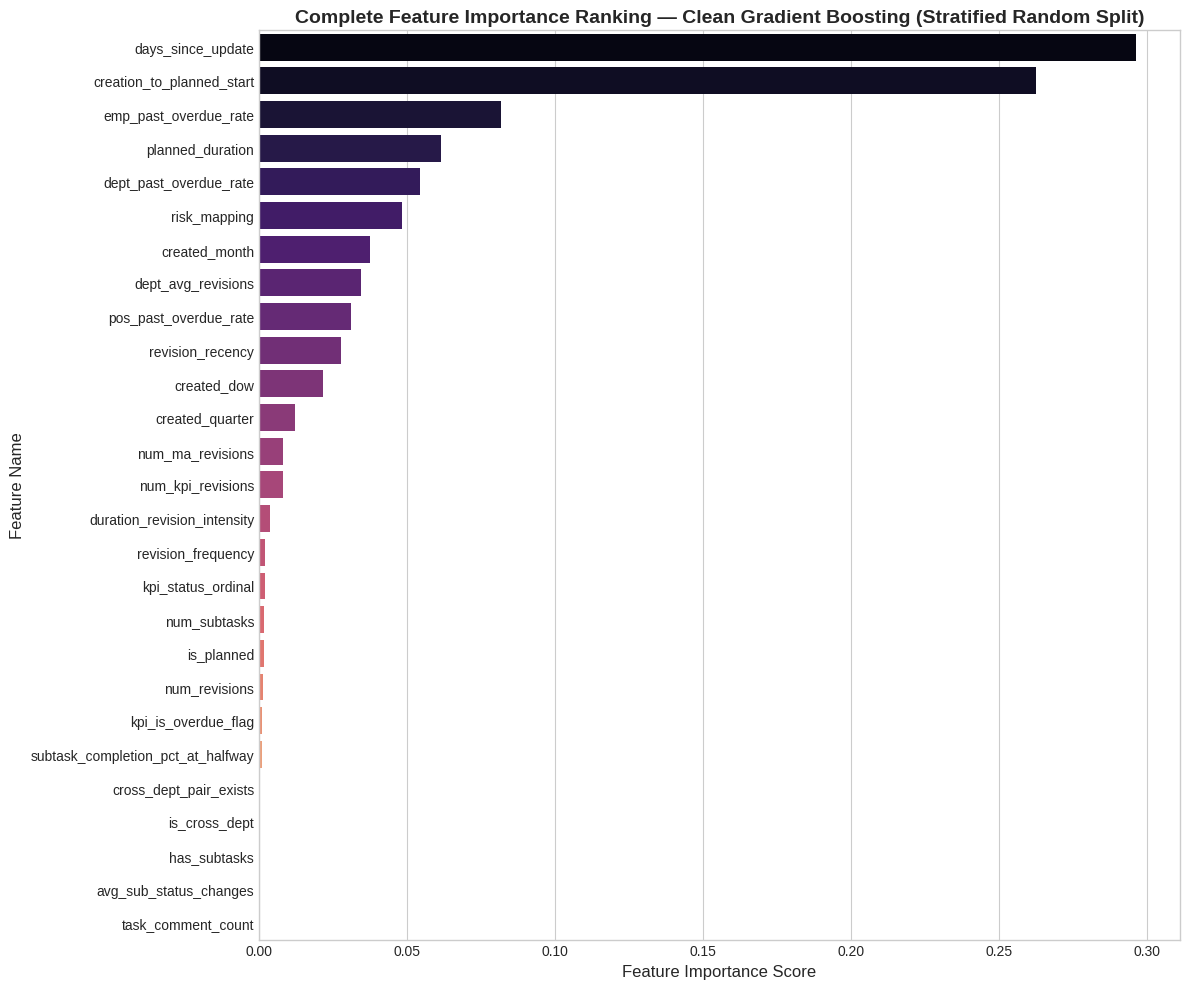

In [29]:
df_all_fi = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_gb_clean.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("=== COMPLETE FEATURE IMPORTANCE RANKING (Gradient Boosting) ===")
print(df_all_fi.to_string())

plt.figure(figsize=(12, 10))
sns.barplot(
    x='Importance',
    y='Feature',
    data=df_all_fi,
    palette='magma'
)
plt.title('Complete Feature Importance Ranking — Clean Gradient Boosting (Stratified Random Split)', fontweight='bold', fontsize=14)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

### Visualizations — PR Curve, ROC Curve & Confusion Matrix

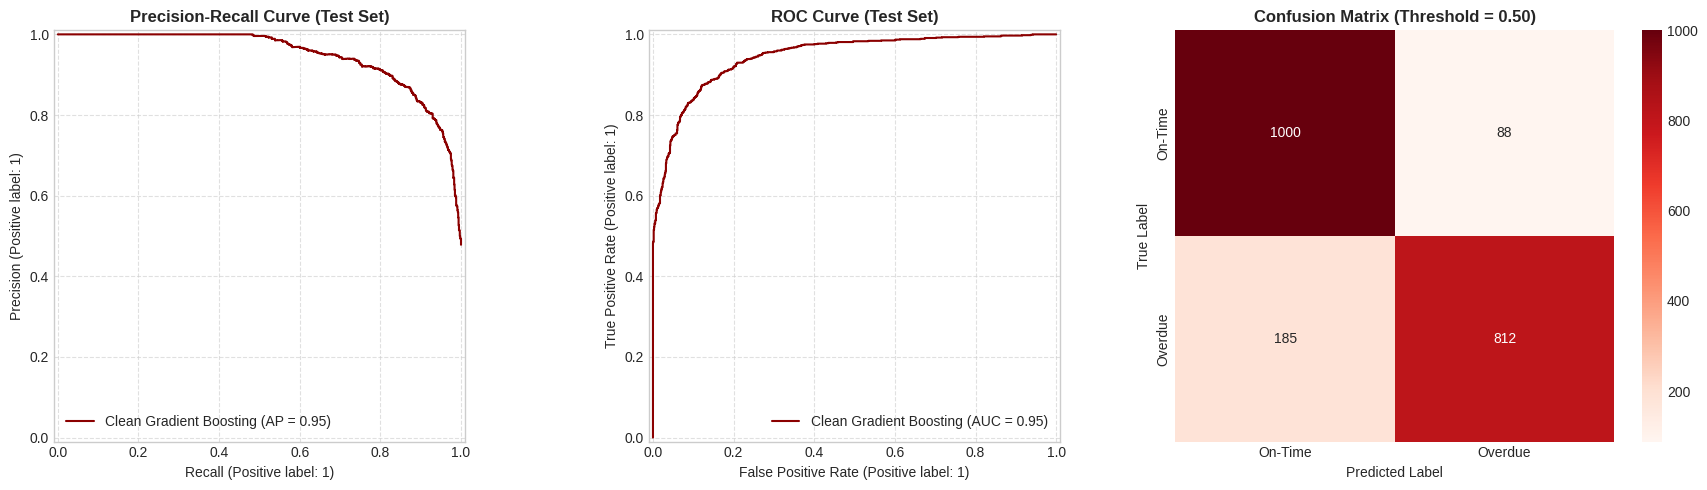

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PR Curve
PrecisionRecallDisplay.from_predictions(
    y_test, y_test_probs, name='Clean Gradient Boosting', ax=axes[0], color='darkred'
)
axes[0].set_title('Precision-Recall Curve (Test Set)', fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. ROC Curve
RocCurveDisplay.from_predictions(
    y_test, y_test_probs, name='Clean Gradient Boosting', ax=axes[1], color='darkred'
)
axes[1].set_title('ROC Curve (Test Set)', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

# 3. Confusion Matrix at Threshold 0.50
cm = confusion_matrix(y_test, (y_test_probs >= 0.50).astype(int))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[2],
            xticklabels=['On-Time', 'Overdue'], yticklabels=['On-Time', 'Overdue'])
axes[2].set_title('Confusion Matrix (Threshold = 0.50)', fontweight='bold')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()